# **Search for Higgs Bosons in the H → ZZ → 2l2q Channel**

## **Project Overview**
This project focuses on searching for a Higgs boson in the mass range of **200-900 GeV** using CMS data and Monte Carlo simulations.

## **Objectives**

### **1. Monte Carlo Simulation Study**
*   **Selection Strategy:** Design a selection strategy based on Monte Carlo simulations to suppress background processes relative to the Higgs signal.
*   **Kinematic Distributions:** Study kinematic distributions to effectively discriminate between signal and background events.

### **2. CMS Data Analysis**
*   **Data Selection:** Analyze real CMS data samples (containing a simulated signal injection) by applying the selection criteria derived from the simulation studies.
*   **Background Comparison:** Compare observed data with background predictions to search for any excess attributable to a signal.
*   **Signal Characterization:** Fit the data to a combination of signal and background to determine key properties of the found Higgs boson signal, including:
    *   Mass and Width
    *   Number of Events
    *   Statistical Significance
    *   Production Cross-section

## Preliminaries

### Read the Data

In [1]:
!pip install mplhep
# Import Essentials
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import mplhep as hep
plt.style.use(hep.style.CMS)
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Load the data
dir = "/content/drive/MyDrive/ExP-CMS/Data/"

ZJets = pd.read_csv(dir+'ZJets.csv')
Higgs350 = pd.read_csv(dir+'Higgs2L2Q_M350.csv')
Higgs400 = pd.read_csv(dir+'Higgs2L2Q_M400.csv')
Higgs500 = pd.read_csv(dir+'Higgs2L2Q_M500.csv')
Data = pd.read_csv(dir+'Real-Data.csv')

# Define luminosities
lumi_data = 19.7
lumi_zjets = 33.4
lumi_higgs350 = 305.0
lumi_higgs400 = 541.0
lumi_higgs500 = 1271.0

### Define the functions

In [3]:
def Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins, xl,dens=True,log=False):
    cols = ["r", "b", "g", "m"]
    bin_edges = np.linspace(x_range[0], x_range[1], bins)

    fig, ax = plt.subplots(figsize=(13, 8))

    for i in range(len(df_name_list)):
        weight = np.full(len(df_name_list[i]), lumi_data / lum_df_list[i])
        ax.hist(df_name_list[i][var], bins=bin_edges, weights=weight,
                histtype='step', color=cols[i], label=label_list[i], linewidth=1.5, density=dens)
    hep.cms.label("Preliminary", data=False, lumi=lumi_data, com=8, ax=ax)

    ax.set_xlabel(xl)
    if dens:
        ax.set_ylabel('Density')
    else:
        ax.set_ylabel('Events')
    ax.legend()
    if log:
        ax.set_yscale("log")
    plt.show()

In [4]:
def kinematic_to_cartesian(df, prefix):
    # Particle 1
    pt1 = df[f'pt{prefix}1']
    eta1 = df[f'eta{prefix}1']
    phi1 = df[f'phi{prefix}1']
    e1 = df[f'e{prefix}1']

    df[f'px{prefix}1'] = pt1 * np.cos(phi1)
    df[f'py{prefix}1'] = pt1 * np.sin(phi1)
    df[f'pz{prefix}1'] = pt1 * np.sinh(eta1)
    df[f'E{prefix}1'] = e1

    # Particle 2
    pt2 = df[f'pt{prefix}2']
    eta2 = df[f'eta{prefix}2']
    phi2 = df[f'phi{prefix}2']
    e2 = df[f'e{prefix}2']

    df[f'px{prefix}2'] = pt2 * np.cos(phi2)
    df[f'py{prefix}2'] = pt2 * np.sin(phi2)
    df[f'pz{prefix}2'] = pt2 * np.sinh(eta2)
    df[f'E{prefix}2'] = e2

    return df

def calculate_invariant_mass(E1, px1, py1, pz1, E2, px2, py2, pz2):
    sum_E = E1 + E2
    sum_px = px1 + px2
    sum_py = py1 + py2
    sum_pz = pz1 + pz2
    return np.sqrt(sum_E**2 - (sum_px**2 + sum_py**2 + sum_pz**2))

def calculate_invariant_mass_four_particles(E1, px1, py1, pz1, E2, px2, py2, pz2, E3, px3, py3, pz3, E4, px4, py4, pz4):
    sum_E = E1 + E2 + E3 + E4
    sum_px = px1 + px2 + px3 + px4
    sum_py = py1 + py2 + py3 + py4
    sum_pz = pz1 + pz2 + pz3 + pz4
    return np.sqrt(sum_E**2 - (sum_px**2 + sum_py**2 + sum_pz**2))

In [50]:
def find_cut(sgn, bkg, var, n_scan=500, minN=10):

  # Arrays with the values
  s_vals = sgn[var].values
  b_vals = bkg[var].values
  N_S_total = len(s_vals)
  N_B_total = len(b_vals)

  # Find the limits of values
  lo = min(s_vals.min(), b_vals.min())
  hi = max(s_vals.max(), b_vals.max())

  # Scan over the combined range of both distributions
  cuts = np.linspace(lo, hi, n_scan)
  S_values = np.full(n_scan, np.nan)
  S_scaled_values = np.full(n_scan, np.nan)

  for i, X in enumerate(cuts):
    N_S = np.sum(s_vals > X)
    N_B = np.sum(b_vals > X)

    if (N_S + N_B) >= minN:
      S_scaled_values[i] = N_S / np.sqrt(N_S + N_B)
    if N_B > 0:
      S_values[i] = N_S / np.sqrt(N_B)

  best_idx = np.nanargmax(S_scaled_values)
  best_cut = cuts[best_idx]

  # Calculate values for the returned dictionary
  total_significance = N_S_total / np.sqrt(N_B_total)
  scaled_significance_at_best_cut = S_scaled_values[best_idx]
  significance_at_best_cut = S_values[best_idx]

  eff_signal = np.sum(s_vals > best_cut) / N_S_total
  eff_bkg = np.sum(b_vals > best_cut) / N_B_total

  return {
      "best_cut": best_cut,
      "total_significance":total_significance,
      "scaled_significance": scaled_significance_at_best_cut,
      "significance": significance_at_best_cut,
      "cuts": cuts,
      "S_scaled_values": S_scaled_values,
      "S_values": S_values,
      "eff_signal": eff_signal,
      "eff_bkg": eff_bkg
  }

def plot_cut(sgn, bkg, var, result, x_range=None, xl=None):
    s_vals  = sgn[var].values
    b_vals  = bkg[var].values
    X_best  = result["best_cut"]

    if x_range:
        bins = np.linspace(x_range[0], x_range[1], 70)
    else:
        bins = np.linspace(min(s_vals.min(), b_vals.min()),
                          max(s_vals.max(), b_vals.max()), 60)

    # Create a single figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.tight_layout(w_pad=3)

    # Plot 1: Distributions
    ax1.hist(b_vals, bins=bins, density=True,
             color="r", label="Background", histtype='step', linewidth=1.5)
    ax1.hist(s_vals, bins=bins, density=True,
             color="b", label="Signal", histtype='step', linewidth=1.5)
    ax1.axvline(X_best, color="k", lw=1.5, ls="--",
                label=f"X = {X_best:.3f}")

    hep.cms.label("", data=False, lumi=lumi_data, com=8, ax=ax1)

    ylim = ax1.get_ylim()

    ax1.set_xlabel(xl if xl else var)
    ax1.set_ylabel("Density")
    ax1.legend()
    ax1.set_ylim(ylim)
    # Plot 2: Significance curve
    ax2.plot(result["cuts"], result["S_scaled_values"],
             color="m", lw=1.5, label=r"$N_S\,/\,\sqrt{N_S + N_B}$")
    ax2.plot(result["cuts"], result["S_values"],
             color="orange", lw=1.5, ls='-.', label=r"$N_S\,/\,\sqrt{N_B}$")
    ax2.axvline(X_best, color="k", lw=1.5, ls="--",
                label=f"X = {X_best:.3f}\n"
                      f"$R_S$ = {result['significance']/result['total_significance']:.2f}\n"
                      f"$ε_{{sig}}$ = {result['eff_signal']:.1%}\n"
                      f"$ε_{{bkg}}$ = {result['eff_bkg']:.1%}")
    ax2.scatter([X_best], [result["scaled_significance"]],
                color="k", zorder=5, s=50)
    ax2.set_xlabel(xl if xl else var,)
    ax2.set_ylabel(r"Significance")
    ax2.legend()

    hep.cms.label("", data=False, lumi=lumi_data, com=8, ax=ax2)

    if x_range:
        ax2.set_xlim(x_range)

    plt.show()

## Proposed Exercises

### A) Simulation Study for Background Discrimination

#### A.1) Study the Kinematic Variables


##### Distributions of $p_T$

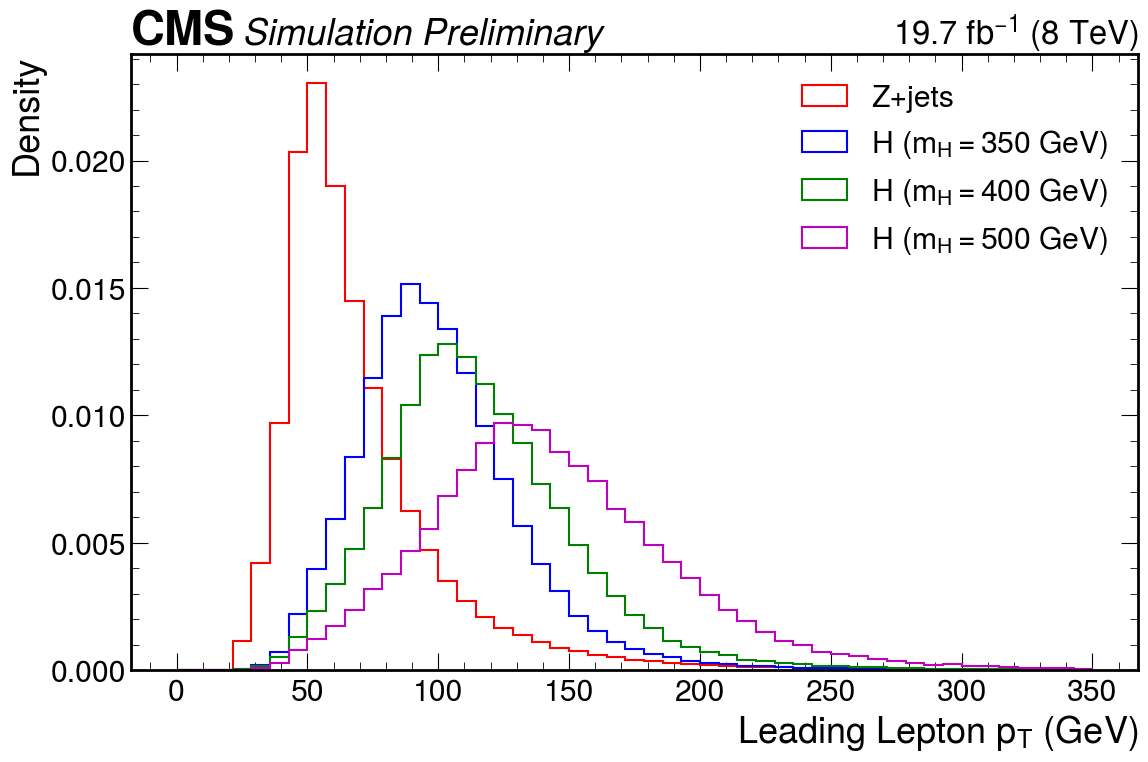

In [ ]:
var = "ptl1"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [0, 350]
bins = 50
xl = "Leading Lepton $p_T$ (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl,True)

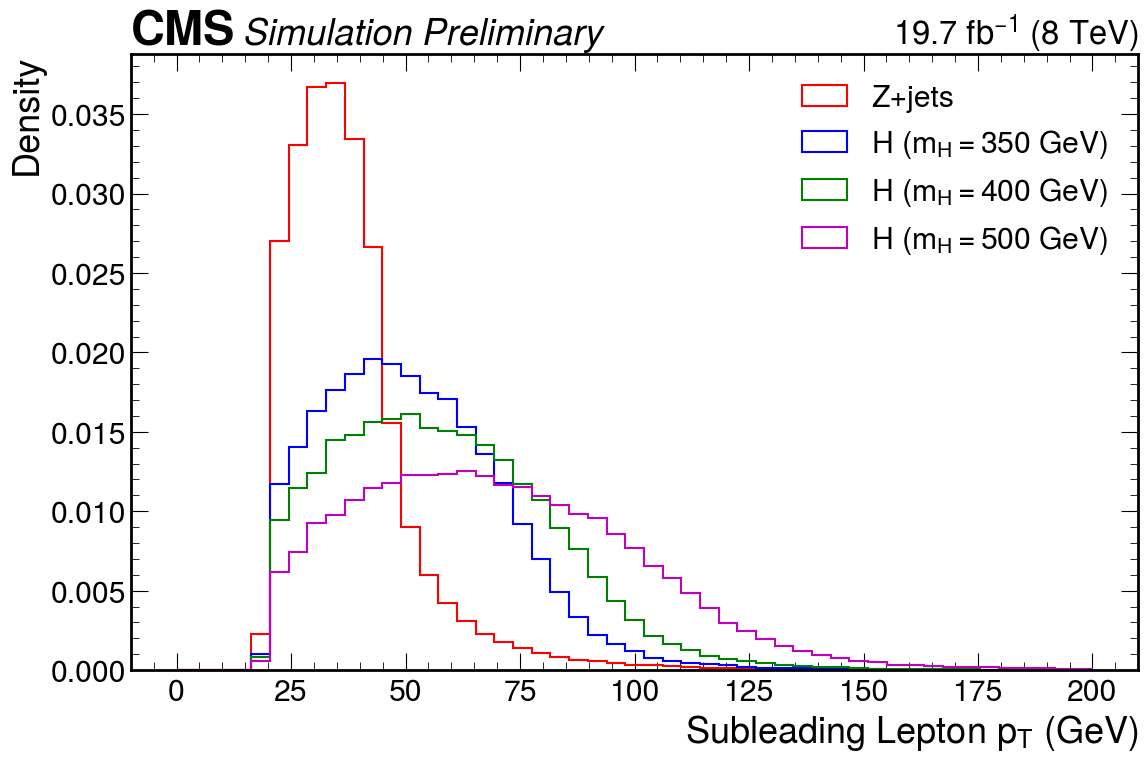

In [ ]:
var = "ptl2"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [0, 200]
bins = 50
xl = "Subleading Lepton $p_T$ (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

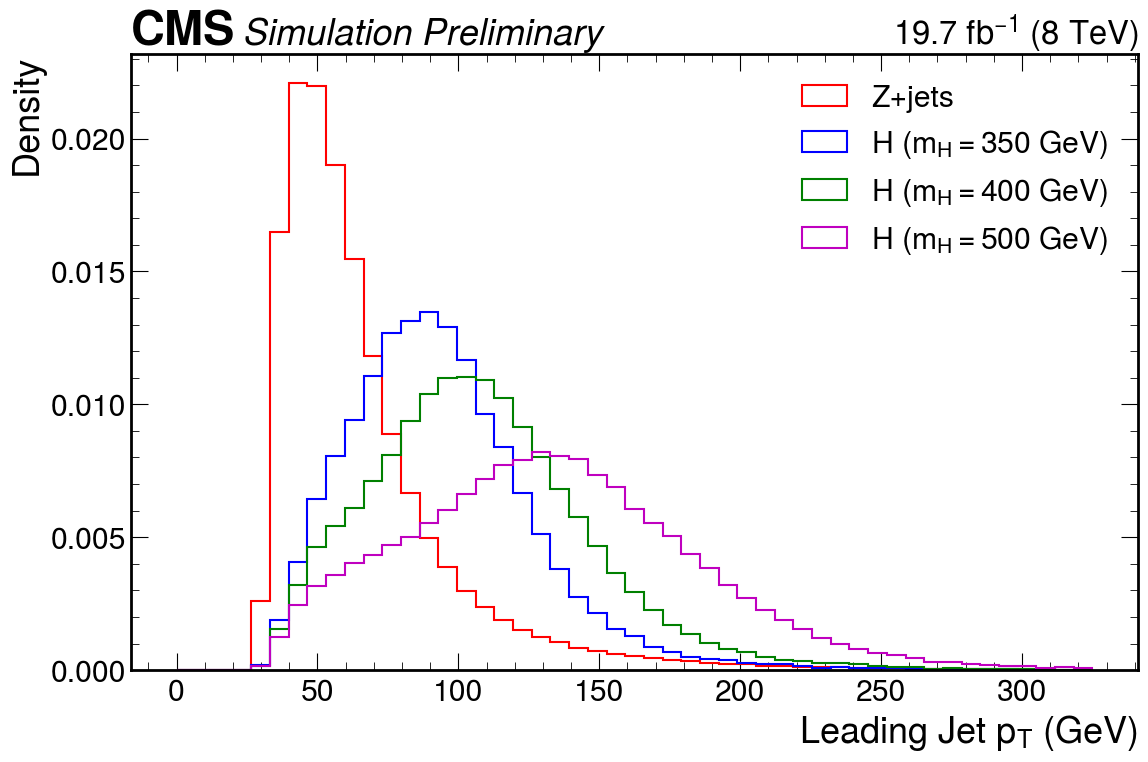

In [ ]:
var = "ptj1"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [0, 325]
bins = 50
xl = "Leading Jet $p_T$ (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

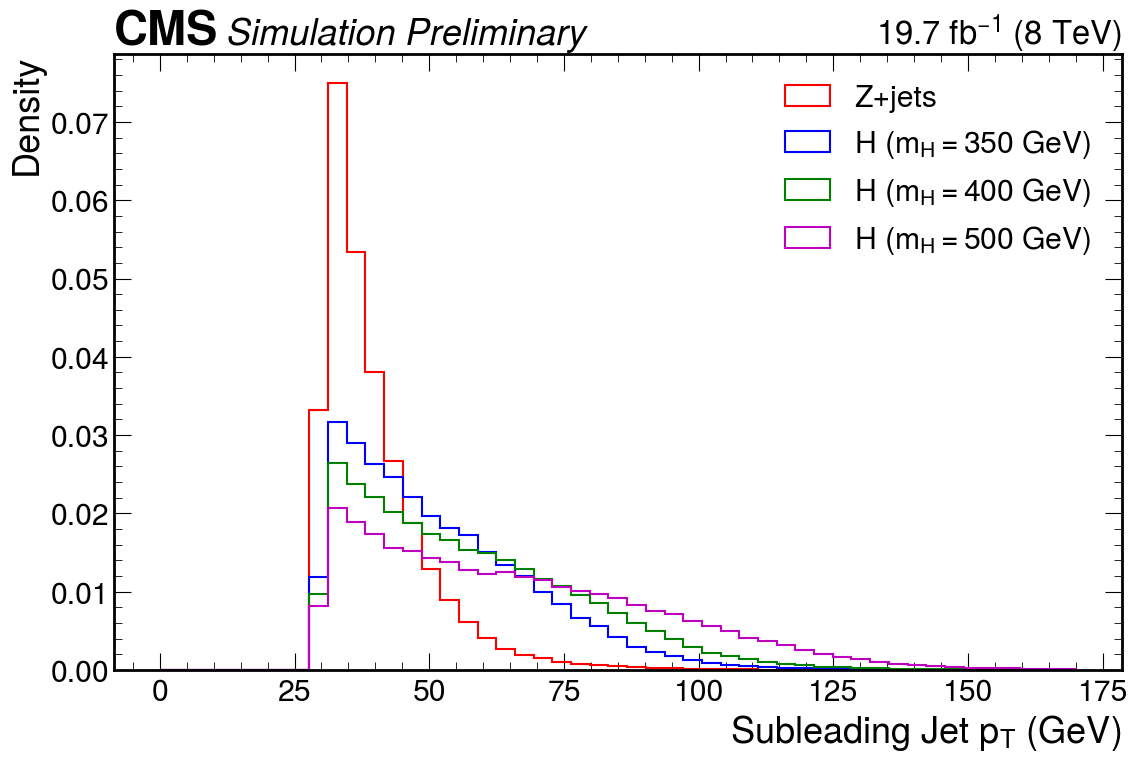

In [ ]:
var = "ptj2"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [0, 170]
bins = 50
xl = "Subleading Jet $p_T$ (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

We can observe a general trend on all of the distributions, the background usually has less $p_T$ than the signal simulations. This behaviour is more noticable in the variabls of the leading lepton and jet.

##### Distributions of $\eta$

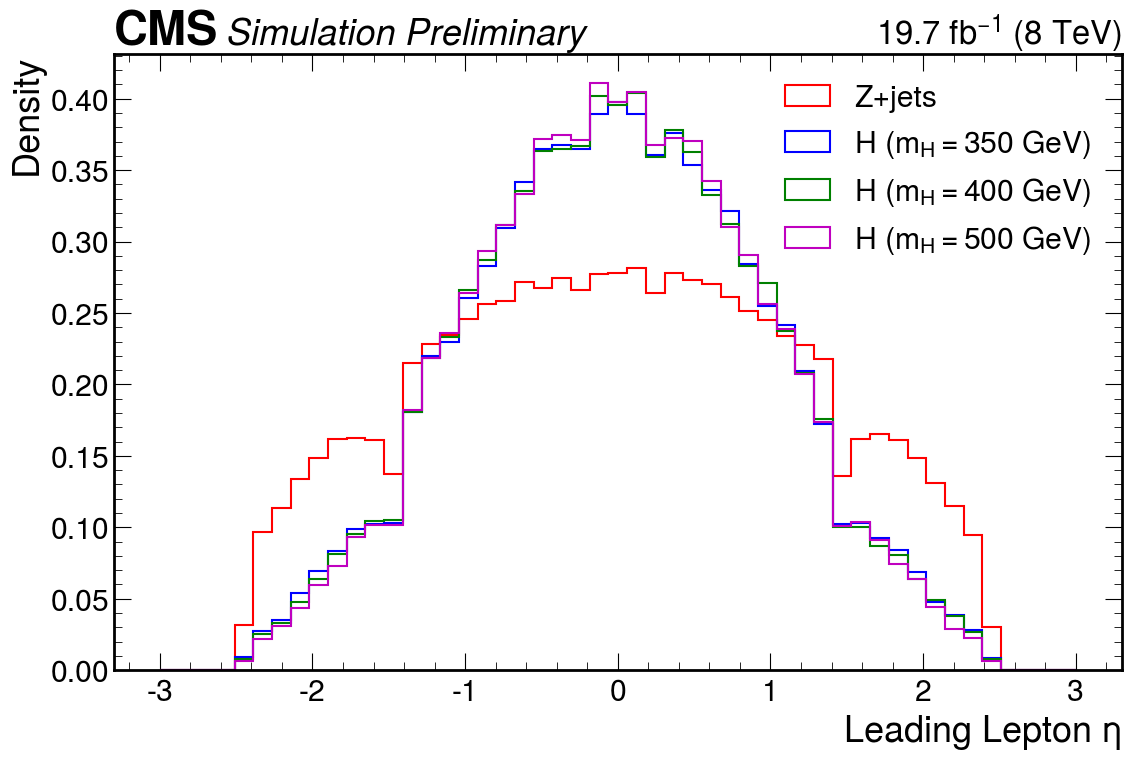

In [ ]:
var = "etal1"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [-3, 3]
bins = 50
xl = r"Leading Lepton $\eta$"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

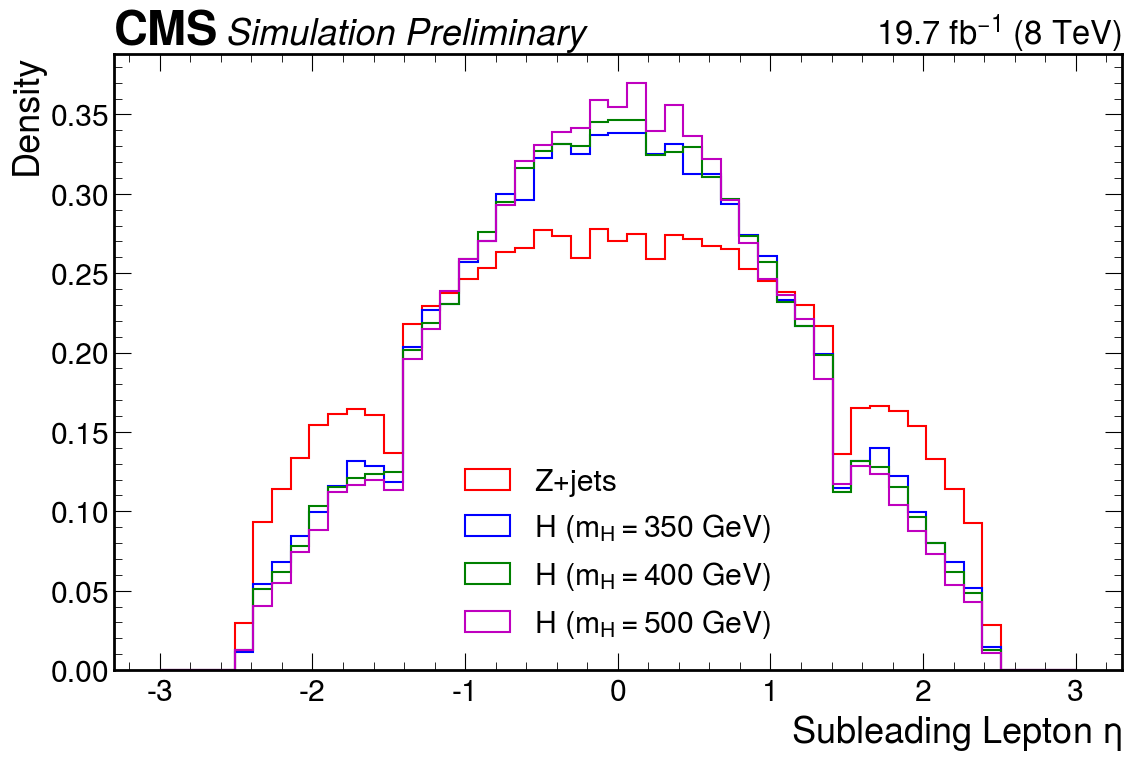

In [ ]:
var = "etal2"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [-3, 3]
bins = 50
xl = r"Subleading Lepton $\eta$"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

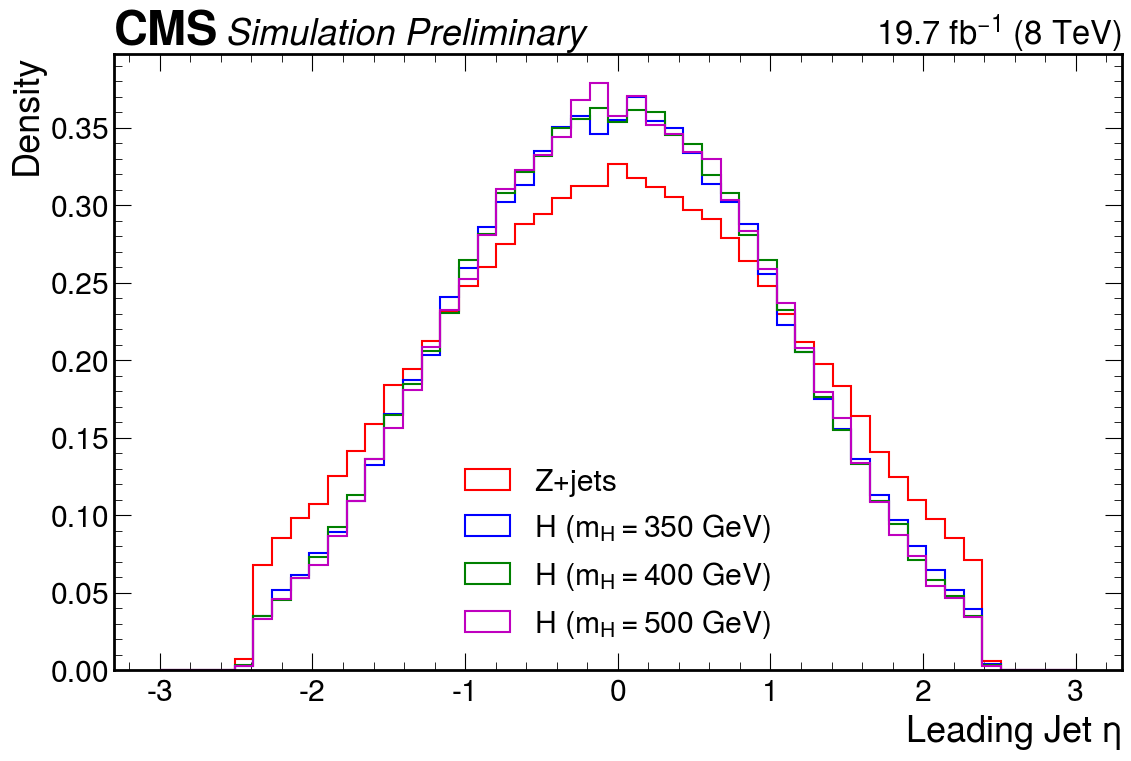

In [ ]:
var = "etaj1"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [-3, 3]
bins = 50
xl = r"Leading Jet $\eta$"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

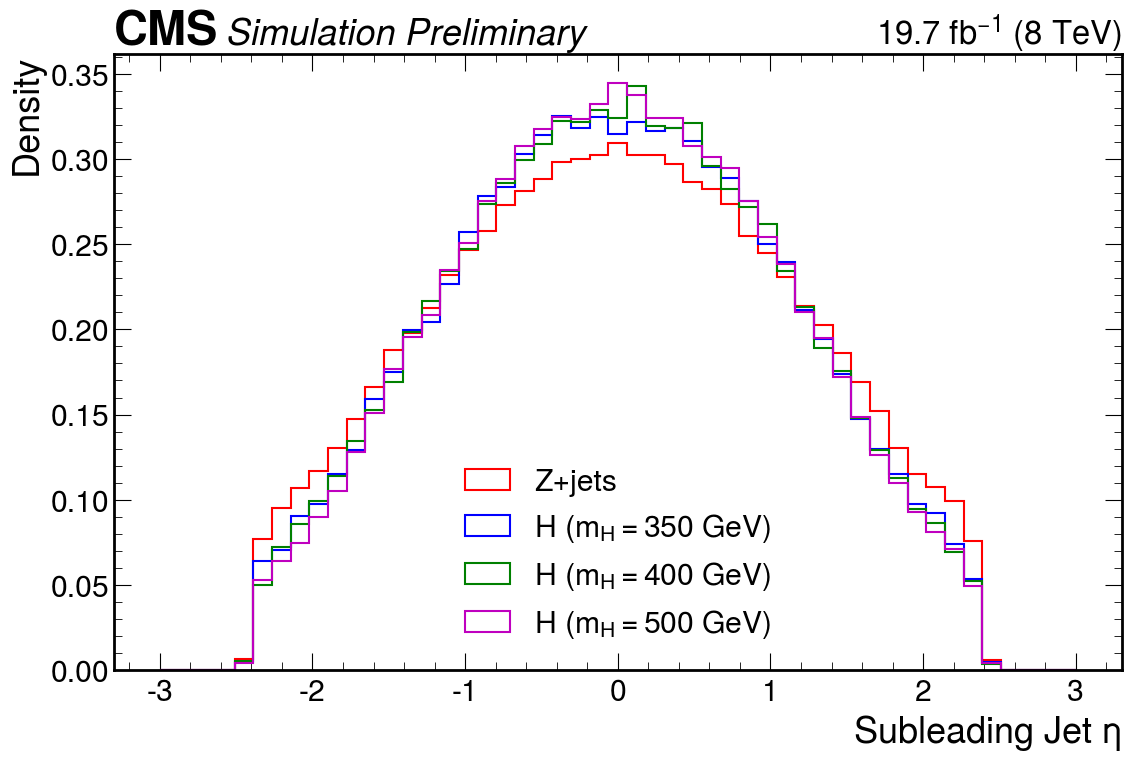

In [ ]:
var = "etaj2"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [-3, 3]
bins = 50
xl = r"Subleading Jet $\eta$"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

Studying the distributions of pseudo rapidity we see two things. Firstly, there is a sharp cutoff at around 2.5, this is not due to any underlying physics but rader due to the detectors limitation (cool to see it reflected). The second observations is that all of the simulations seem to follow the same centered normal distribution, while in the lepton case the signal distribution is narrower than that of the data, in the case of the jets, this distinctions is harder to see.

##### Distributions of $\varphi$

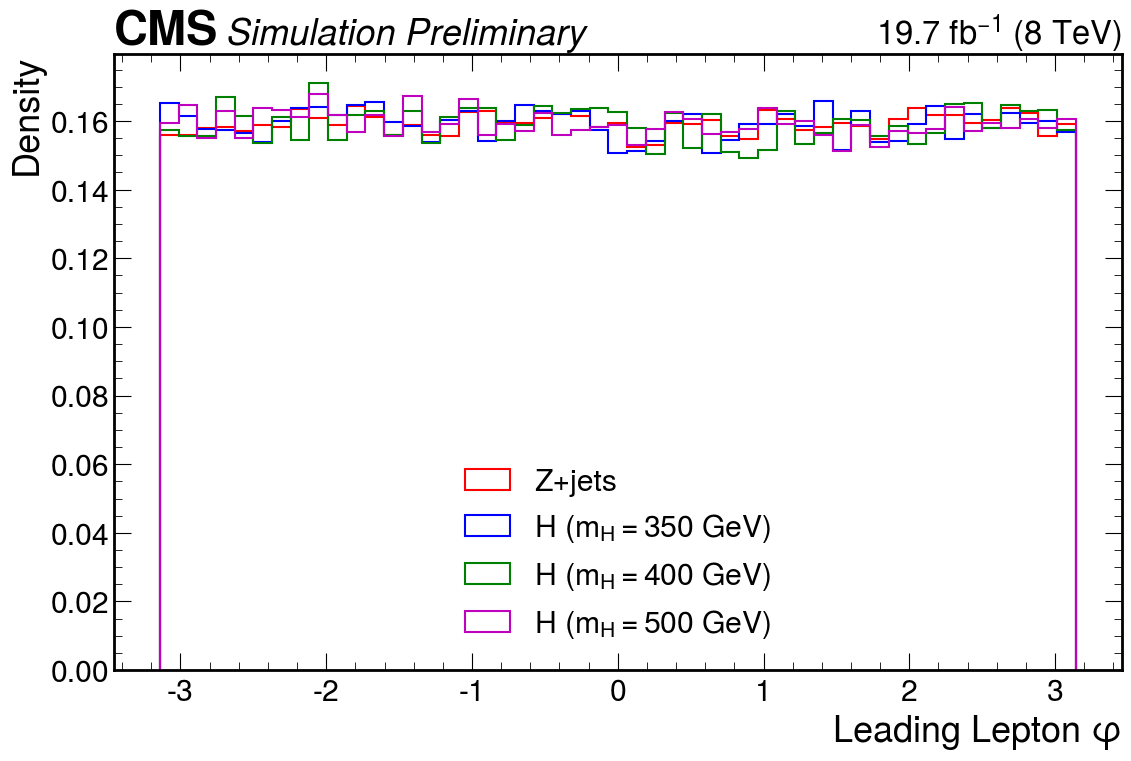

In [ ]:
var = "phil1"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [-np.pi, np.pi]
bins = 50
xl = r"Leading Lepton $\varphi$"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

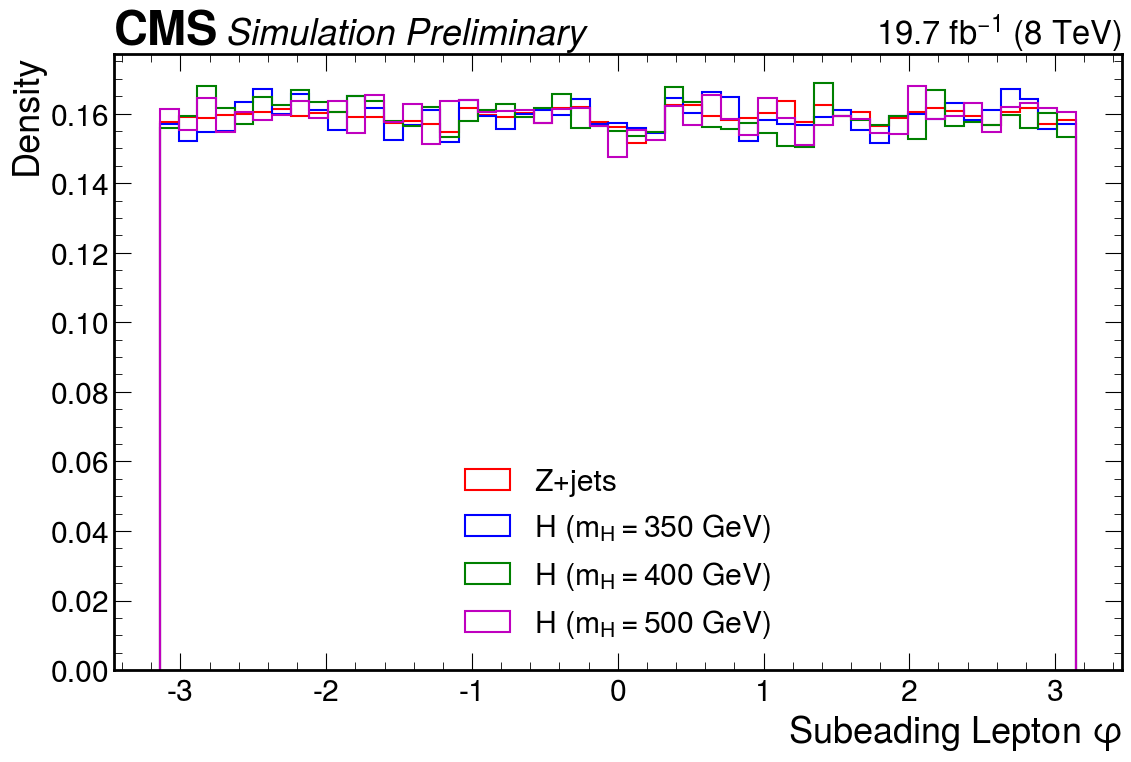

In [ ]:
var = "phil2"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [-np.pi, np.pi]
bins = 50
xl = r"Subeading Lepton $\varphi$"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

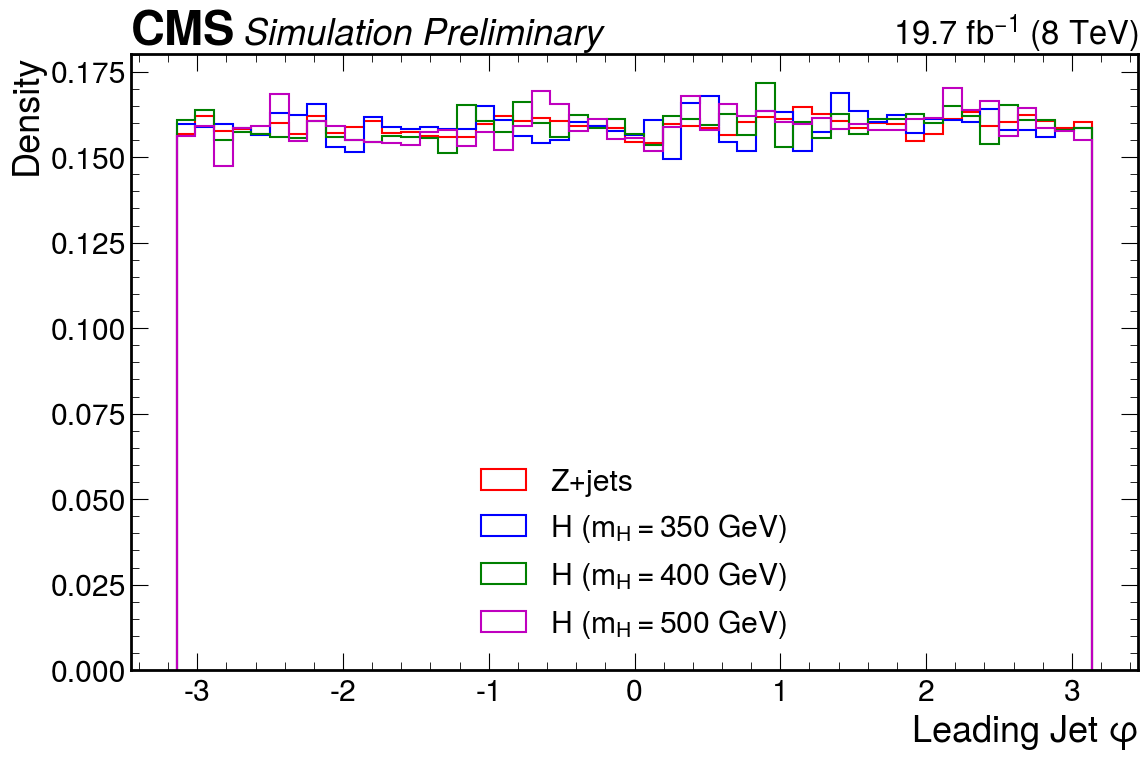

In [ ]:
var = "phij1"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [-np.pi, np.pi]
bins = 50
xl = r"Leading Jet $\varphi$"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

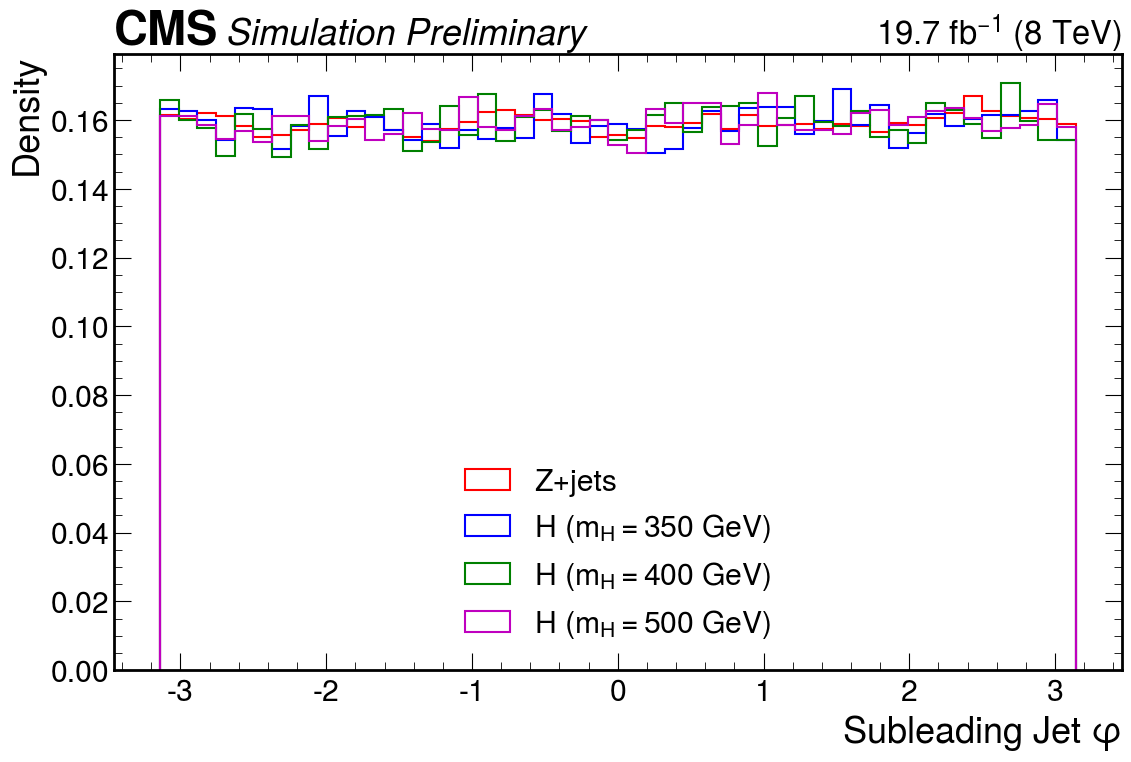

In [ ]:
var = "phij2"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [-np.pi, np.pi]
bins = 50
xl = r"Subleading Jet $\varphi$"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

All of the distributions are constant since the collider presents cylindical symetry.

##### Distributions of $E$

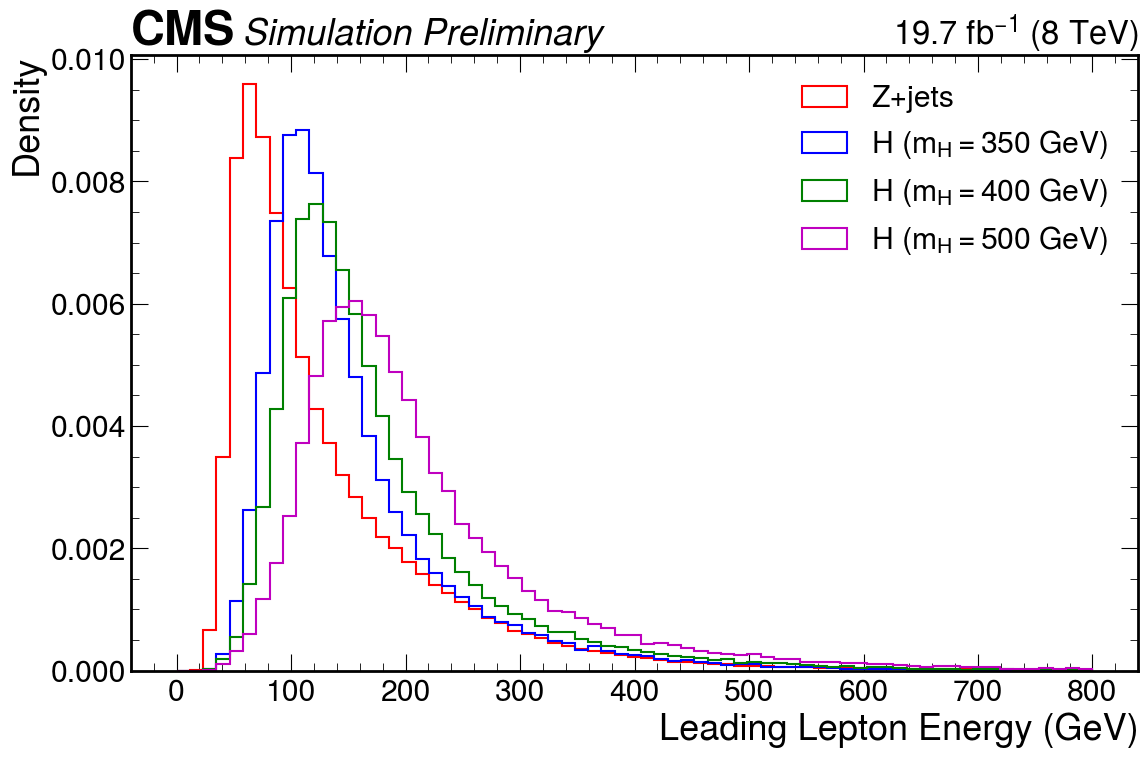

In [ ]:
var = "el1"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [0, 800]
bins = 70
xl = r"Leading Lepton Energy (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

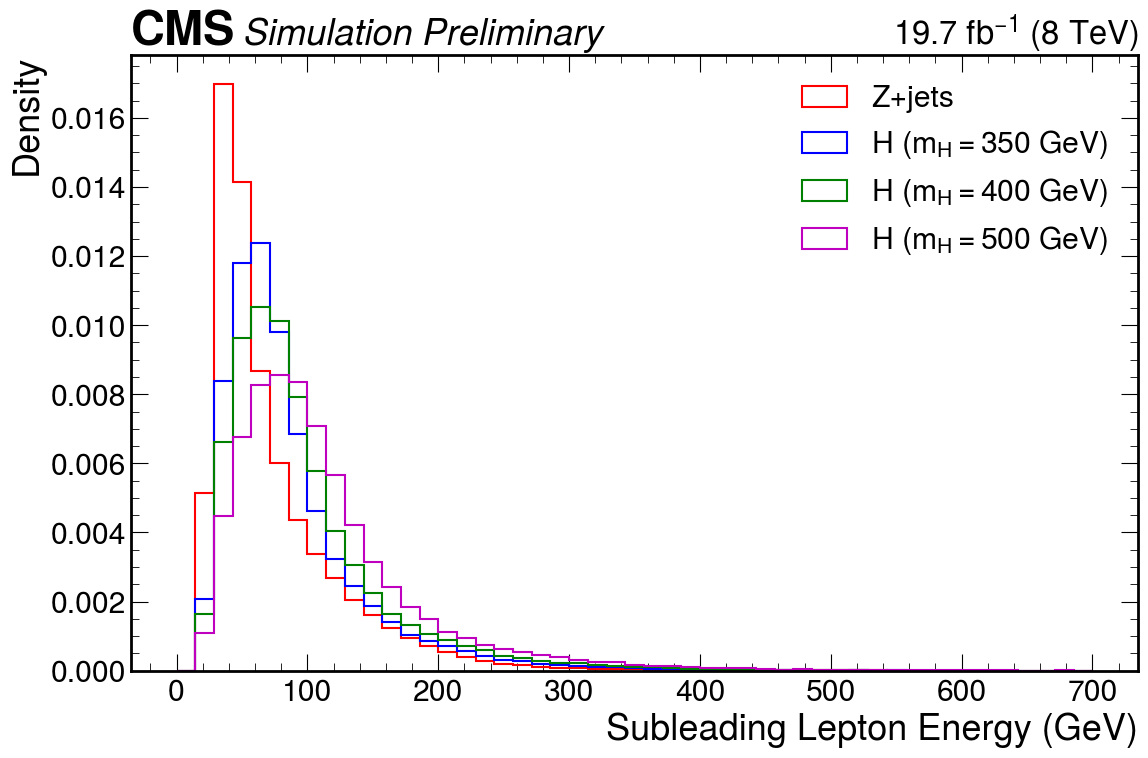

In [ ]:
var = "el2"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [0, 700]
bins = 50
xl = r"Subleading Lepton Energy (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

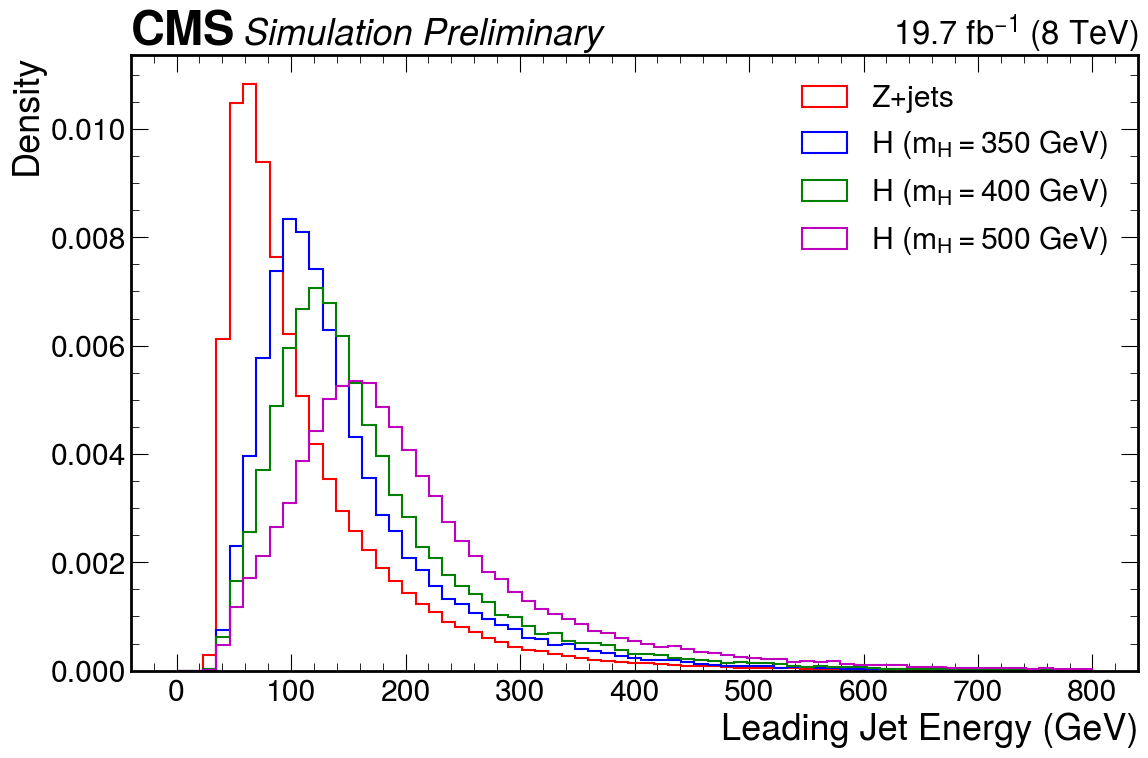

In [ ]:
var = "ej1"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [0, 800]
bins = 70
xl = r"Leading Jet Energy (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

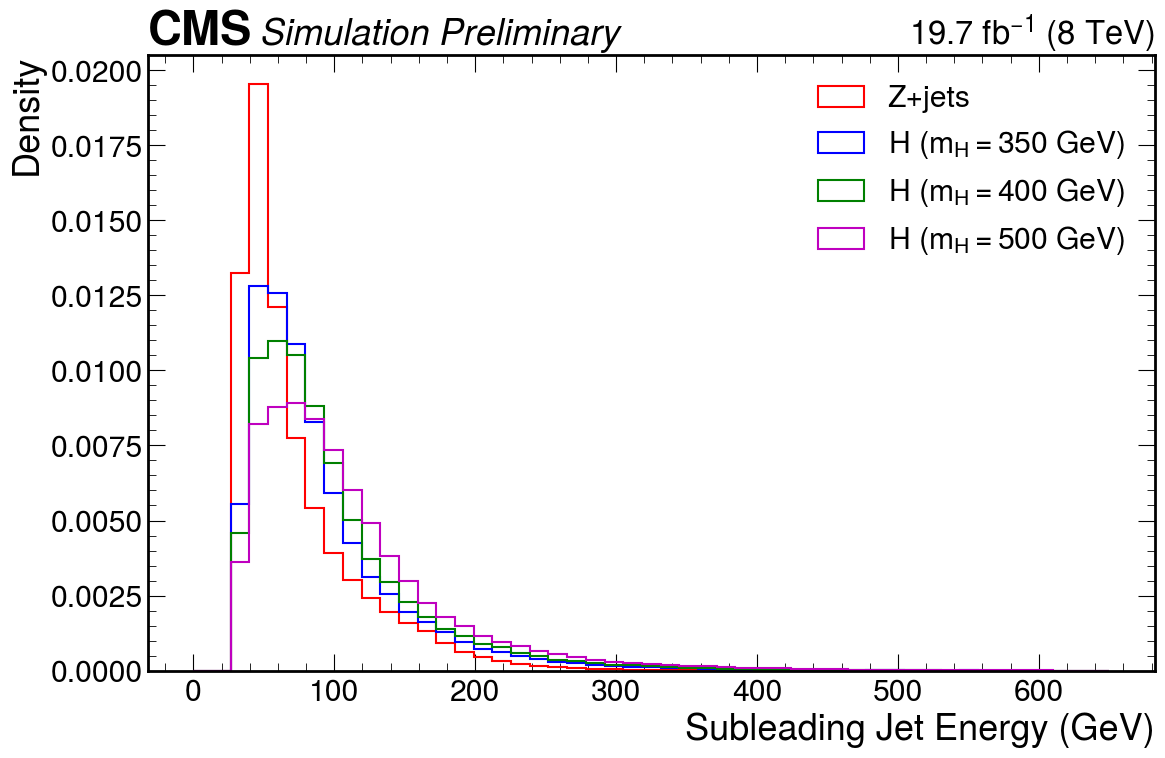

In [ ]:
var = "ej2"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [0, 650]
bins = 50
xl = r"Subleading Jet Energy (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

#### A.2) Invariant Mass

In [15]:
# List of dataframes to process
df_list = [ZJets, Higgs350, Higgs400, Higgs500, Data]
df_names = ['ZJets', 'Higgs350', 'Higgs400', 'Higgs500', 'Data']

for i, df in enumerate(df_list):
    # Convert lepton kinematic variables to Cartesian coordinates
    df = kinematic_to_cartesian(df, 'l')

    # Convert jet kinematic variables to Cartesian coordinates
    df = kinematic_to_cartesian(df, 'j')

    # Calculate Mll (dilepton invariant mass)
    df['Mll'] = calculate_invariant_mass(df['El1'], df['pxl1'], df['pyl1'], df['pzl1'],
                                        df['El2'], df['pxl2'], df['pyl2'], df['pzl2'])

    # Calculate Mjj (dijet invariant mass)
    df['Mjj'] = calculate_invariant_mass(df['Ej1'], df['pxj1'], df['pyj1'], df['pzj1'],
                                        df['Ej2'], df['pxj2'], df['pyj2'], df['pzj2'])

    # Calculate Mlljj (total invariant mass of the 2-lepton, 2-jet system)
    df['Mlljj'] = calculate_invariant_mass_four_particles(df['El1'], df['pxl1'], df['pyl1'], df['pzl1'],
                                                        df['El2'], df['pxl2'], df['pyl2'], df['pzl2'],
                                                        df['Ej1'], df['pxj1'], df['pyj1'], df['pzj1'],
                                                        df['Ej2'], df['pxj2'], df['pyj2'], df['pzj2'])

    df_list[i] = df # Update the dataframe in the list

    print(f"Updated {df_names[i]} with Cartesian coordinates and invariant masses.")
    display(df.head())

# Reassign the modified dataframes back to their original names
ZJets, Higgs350, Higgs400, Higgs500, Data = df_list

Updated ZJets with Cartesian coordinates and invariant masses.


,ptl1,etal1,phil1,el1,ptl2,etal2,phil2,el2,ptj1,etaj1,...,pyj1,pzj1,Ej1,pxj2,pyj2,pzj2,Ej2,Mll,Mjj,Mlljj
0,41.8386,1.180040,-1.003560,74.5097,36.9270,2.281210,2.44485,182.6160,51.5563,0.492734,...,42.220584,26.444034,60.1287,-34.071245,-0.891257,68.744261,77.4771,90.032294,90.257053,205.271745
1,76.4200,-1.023810,2.045960,120.0940,39.9469,-1.590010,-2.48043,102.0190,62.7528,-1.511750,...,-35.290386,-135.362050,149.7640,-28.691984,-13.137315,-22.514195,40.0302,90.772426,90.628751,221.727075
2,65.9138,-0.835671,-0.599785,90.3001,36.3745,0.126606,1.26652,36.6665,74.4379,0.620148,...,-8.471446,49.178826,90.9490,-15.704903,-30.349551,-26.483572,44.6109,92.673967,91.189763,255.803799
3,53.1808,1.862370,1.868220,175.3450,42.5112,2.002230,-1.74277,160.2800,37.3547,2.169210,...,-33.074827,161.318137,165.7930,-30.876358,3.322454,114.237203,118.8100,92.729889,63.247713,162.183435
4,53.0637,0.971798,-1.417920,80.1552,40.0653,0.807336,2.17254,53.8474,35.9184,-0.948500,...,18.013553,-39.411688,54.1088,-5.452219,-31.862887,8.854662,34.5791,90.224864,77.996737,209.936419


Updated Higgs350 with Cartesian coordinates and invariant masses.


,ptl1,etal1,phil1,el1,ptl2,etal2,phil2,el2,ptj1,etaj1,...,pyj1,pzj1,Ej1,pxj2,pyj2,pzj2,Ej2,Mll,Mjj,Mlljj
0,94.9096,0.485836,1.95082,106.333,64.8346,0.640480,0.882512,78.5936,125.3480,1.223570,...,-123.315794,194.610512,232.216,29.210705,-17.139504,-7.065756,35.6909,80.792099,129.723067,355.724425
1,179.8530,0.536273,-2.98959,206.341,35.6912,-0.331985,-2.263330,37.6761,98.7843,1.464450,...,-98.596717,202.209419,225.972,-28.355623,-82.347734,80.904210,120.0490,91.600910,79.626152,323.165953
2,147.8700,-0.346469,-2.82993,156.834,38.7896,0.357497,2.516010,41.2948,101.6120,-0.401939,...,9.955473,-41.950443,111.312,92.526133,19.265235,72.141263,120.5900,87.418434,120.470601,429.371636
3,83.5835,2.107860,0.42037,349.051,63.3516,0.879139,0.137986,89.4514,102.7680,1.481640,...,-5.458794,214.419849,238.751,-30.496225,-68.757380,94.651898,121.4090,97.330797,104.695434,362.150772
4,140.0660,0.272572,2.12036,145.301,32.5251,1.081510,0.927222,53.4746,69.2192,-1.183920,...,-65.358884,-102.481788,124.389,44.309759,-10.399143,-9.909773,48.2267,94.332605,83.200230,363.197804


Updated Higgs400 with Cartesian coordinates and invariant masses.


,ptl1,etal1,phil1,el1,ptl2,etal2,phil2,el2,ptj1,etaj1,...,pyj1,pzj1,Ej1,pxj2,pyj2,pzj2,Ej2,Mll,Mjj,Mlljj
0,79.9147,0.500364,1.804800,90.1291,52.6493,-0.658979,1.729180,64.5007,108.6570,0.968333,...,-85.945111,122.447484,164.588,-17.842011,-41.256868,18.372509,49.8781,79.634896,87.288604,338.609978
1,100.7310,0.019000,1.739010,100.7490,56.3729,-0.754048,0.949804,73.1734,106.9070,0.277544,...,-98.827812,30.053801,113.102,16.283469,-37.648575,-1.351323,42.3818,83.203882,64.233940,328.789945
2,73.6351,0.983680,1.840050,112.2280,27.0459,0.971595,-0.896097,40.8479,157.5780,-1.189730,...,-155.340641,-234.940163,286.220,-9.202913,-42.253401,-4.486792,44.8999,87.427563,109.544053,442.428889
3,127.1460,-0.414594,-0.797656,138.2300,69.6303,-1.111070,-1.444780,117.2170,95.2809,-0.232577,...,62.923602,-22.360468,99.325,-36.927786,82.112263,-118.748233,149.8210,89.726309,96.745726,412.768112
4,118.0750,0.805792,-2.940170,158.5280,58.5497,0.109280,2.473840,58.8998,129.5070,0.579407,...,-30.611534,79.306793,153.240,65.474588,43.076783,78.122613,112.4270,91.618407,95.075549,398.969447


Updated Higgs500 with Cartesian coordinates and invariant masses.


,ptl1,etal1,phil1,el1,ptl2,etal2,phil2,el2,ptj1,etaj1,...,pyj1,pzj1,Ej1,pxj2,pyj2,pzj2,Ej2,Mll,Mjj,Mlljj
0,154.437,-0.666980,-0.012289,190.082,142.2860,-0.055783,-0.067483,142.5080,152.8450,0.054936,...,-51.949441,8.400917,156.937,-25.052283,-18.649121,-36.218557,48.8356,92.387082,89.953313,495.310309
1,159.711,-1.694390,-2.455440,449.350,99.3573,-2.007460,-3.079950,376.5010,39.6641,-1.949480,...,38.553808,-136.497764,142.700,35.981869,-6.472058,-14.205571,40.4505,86.948248,88.040892,329.903419
2,151.266,-0.945406,-2.069530,224.054,63.5099,-1.519440,-2.707680,152.0580,119.2300,0.975929,...,91.657933,135.730787,182.171,-48.649293,-11.163947,78.693560,93.9272,83.872491,90.401291,588.422853
3,125.152,1.054440,0.138700,201.417,103.4130,0.354095,-0.285123,109.9640,147.0510,1.841190,...,-9.911460,451.844126,475.719,-65.899674,-15.971962,77.466100,103.5070,94.350227,97.251291,516.459199
4,158.221,-0.678529,2.780160,196.062,51.7242,0.218904,-3.116520,52.9685,188.7830,-1.322760,...,-50.491168,-329.177941,380.616,34.732778,10.100435,-23.280410,43.9300,90.844375,86.306432,494.489120


Updated Data with Cartesian coordinates and invariant masses.


,ptl1,etal1,phil1,el1,ptl2,etal2,phil2,el2,ptj1,etaj1,...,pyj1,pzj1,Ej1,pxj2,pyj2,pzj2,Ej2,Mll,Mjj,Mlljj
0,48.6791,1.411850,-0.017499,105.8100,39.0320,2.286650,-2.474900,194.0580,35.0305,1.500920,...,10.719800,74.665569,82.8740,33.120098,3.444207,-4.258137,34.3513,91.073845,92.649299,218.864908
1,96.7672,-0.605772,-2.850610,115.0720,31.7025,0.137944,-1.130830,32.0048,94.8779,1.599500,...,61.010389,225.266655,245.3390,29.162216,7.077659,94.167073,99.0823,93.930214,100.299762,397.457009
2,49.8984,2.132750,-2.904530,213.4790,25.0988,0.669483,0.873248,30.9369,31.7534,2.080900,...,-7.361066,125.217284,129.5700,2.102231,-30.805553,-23.237026,39.1951,87.835447,124.645953,249.871190
3,70.7834,-0.443097,1.605200,77.8465,58.7033,-0.384618,-3.117100,63.0992,46.5348,0.694302,...,-29.995230,34.968297,59.1299,14.740000,-31.103939,-73.764301,81.8599,90.787249,110.036416,265.338322
4,142.8270,-1.290860,-1.347250,279.2940,121.5680,-1.594720,-2.006980,311.8150,38.5231,-0.058099,...,-2.255879,-2.239421,39.6538,29.984062,18.472366,70.347202,79.2325,94.340446,95.710593,488.030466


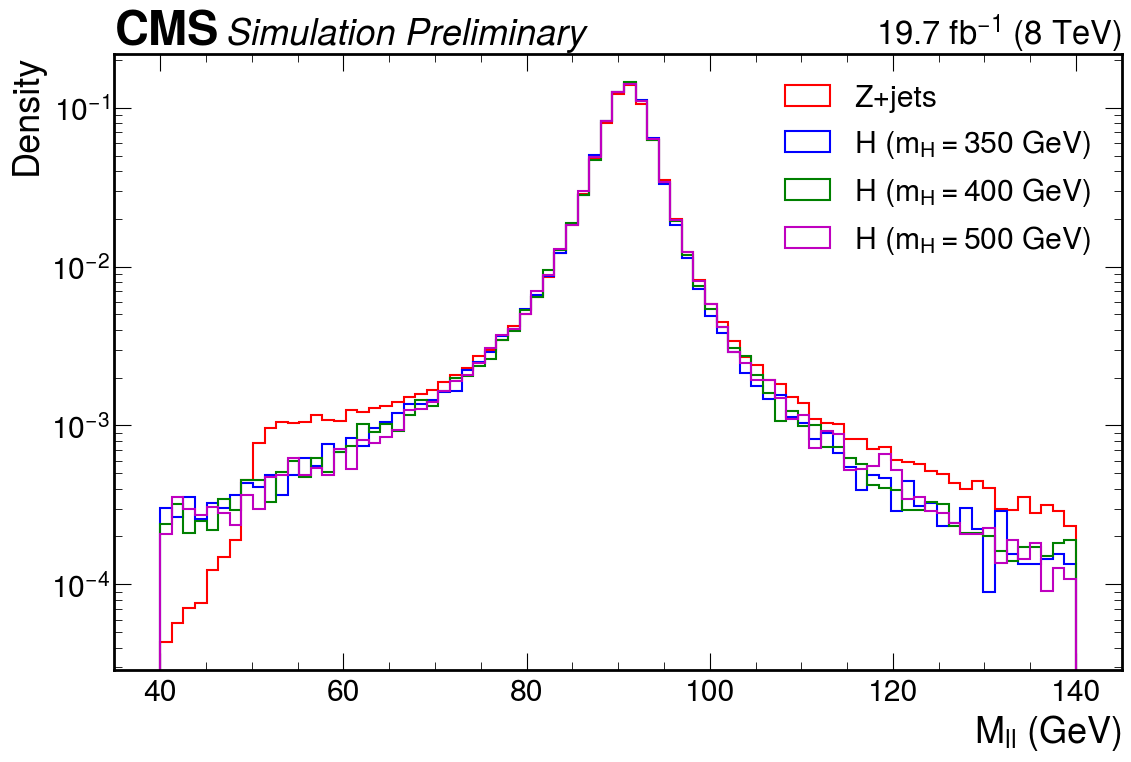

In [ ]:
var = "Mll"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [40, 140]
bins = 80
xl = r"$M_{ll}$ (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl,log=True)

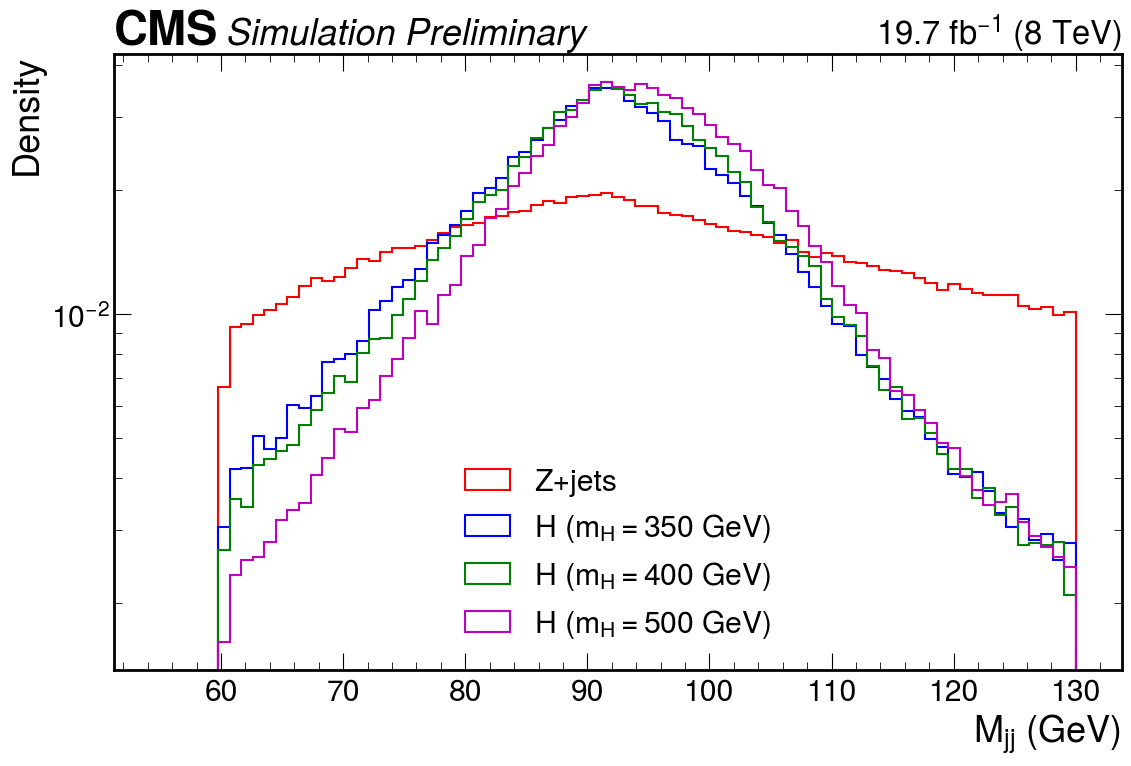

In [ ]:
var = "Mjj"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [55, 130]
bins = 80
xl = r"$M_{jj}$ (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl,log=True)

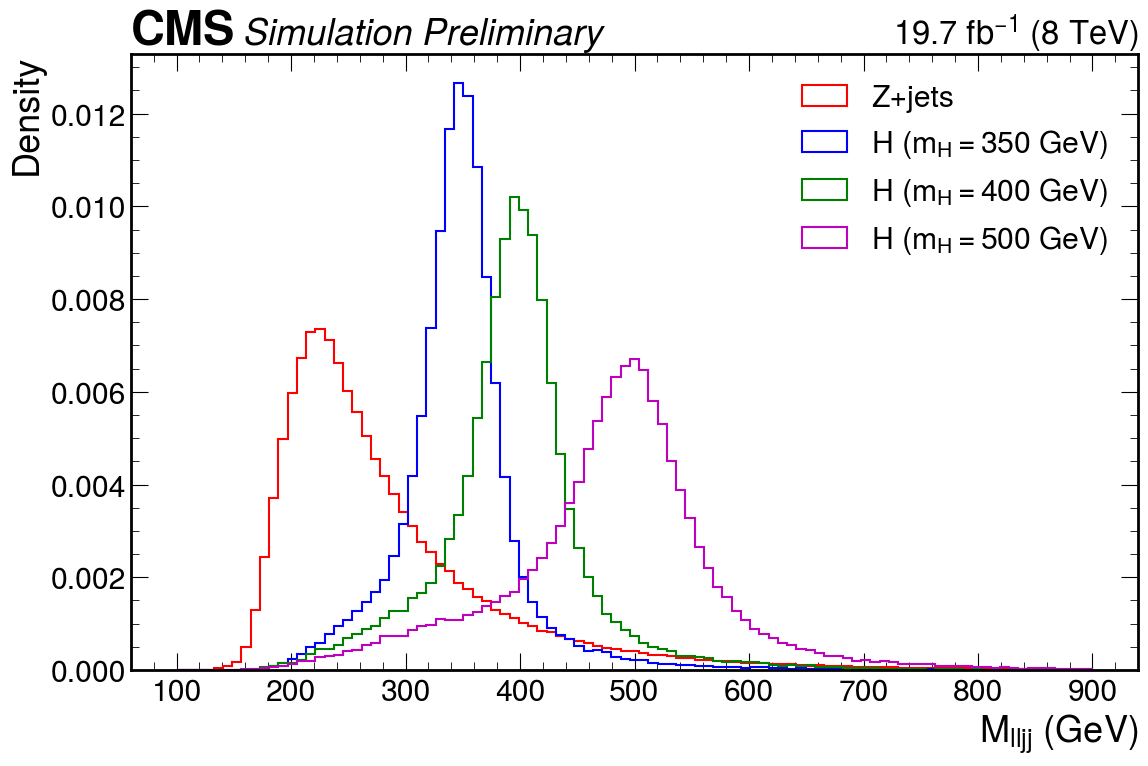

In [17]:
var = "Mlljj"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [100, 900]
bins = 100
xl = r"$M_{lljj}$ (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl,log=False)

#### A.3) Angular likelihood Discriminant

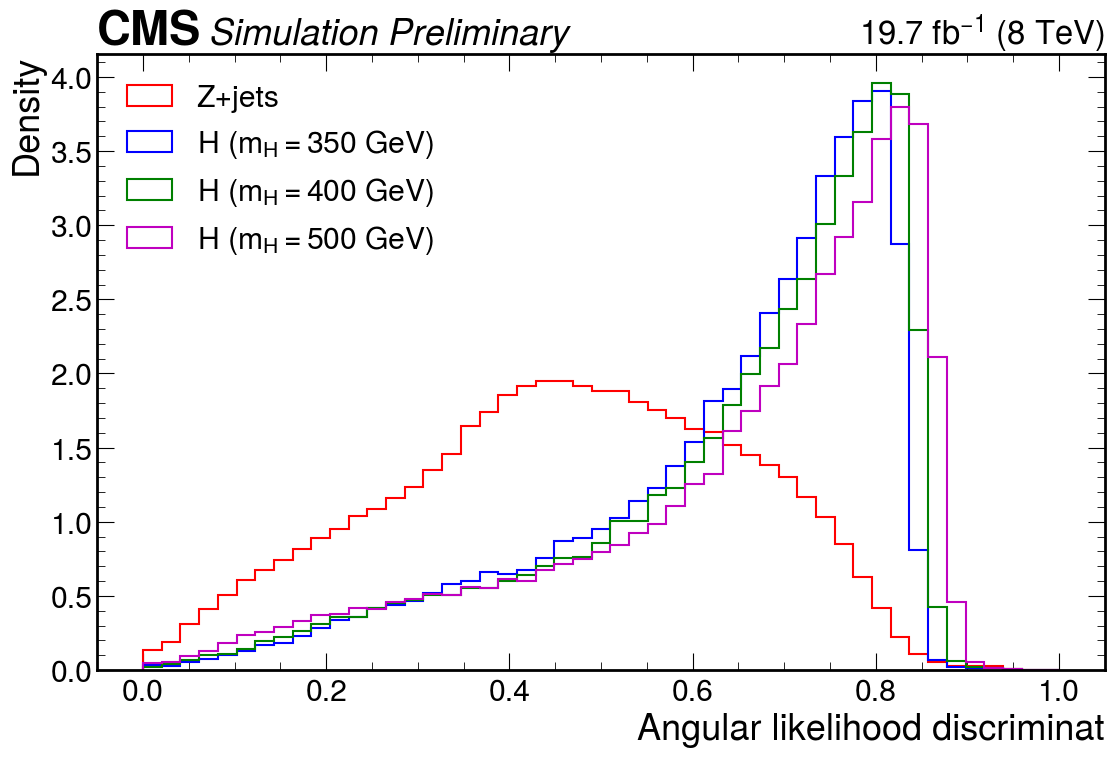

In [ ]:
var = "ld"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [0, 1]
bins = 50
xl = r"Angular likelihood discriminat"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

#### A.4) Derived Kinematic Variables

In [24]:
# Calculate new variables: sum of lepton pT and sum of all pT
df_list = [ZJets, Higgs350, Higgs400, Higgs500]

for df in df_list:
    df['ptl_sum'] = df['ptl1'] + df['ptl2']
    df['pt_all_sum'] = df['ptl1'] + df['ptl2'] + df['ptj1'] + df['ptj2']

print("New variables 'ptl_sum' and 'pt_all_sum' added to all dataframes.")
display(ZJets.head())

New variables 'ptl_sum' and 'pt_all_sum' added to all dataframes.


,ptl1,etal1,phil1,el1,ptl2,etal2,phil2,el2,ptj1,etaj1,...,Ej1,pxj2,pyj2,pzj2,Ej2,Mll,Mjj,Mlljj,ptl_sum,pt_all_sum
0,41.8386,1.180040,-1.003560,74.5097,36.9270,2.281210,2.44485,182.6160,51.5563,0.492734,...,60.1287,-34.071245,-0.891257,68.744261,77.4771,90.032294,90.257053,205.271745,78.7656,164.4048
1,76.4200,-1.023810,2.045960,120.0940,39.9469,-1.590010,-2.48043,102.0190,62.7528,-1.511750,...,149.7640,-28.691984,-13.137315,-22.514195,40.0302,90.772426,90.628751,221.727075,116.3669,210.6763
2,65.9138,-0.835671,-0.599785,90.3001,36.3745,0.126606,1.26652,36.6665,74.4379,0.620148,...,90.9490,-15.704903,-30.349551,-26.483572,44.6109,92.673967,91.189763,255.803799,102.2883,210.8984
3,53.1808,1.862370,1.868220,175.3450,42.5112,2.002230,-1.74277,160.2800,37.3547,2.169210,...,165.7930,-30.876358,3.322454,114.237203,118.8100,92.729889,63.247713,162.183435,95.6920,164.1013
4,53.0637,0.971798,-1.417920,80.1552,40.0653,0.807336,2.17254,53.8474,35.9184,-0.948500,...,54.1088,-5.452219,-31.862887,8.854662,34.5791,90.224864,77.996737,209.936419,93.1290,161.3734


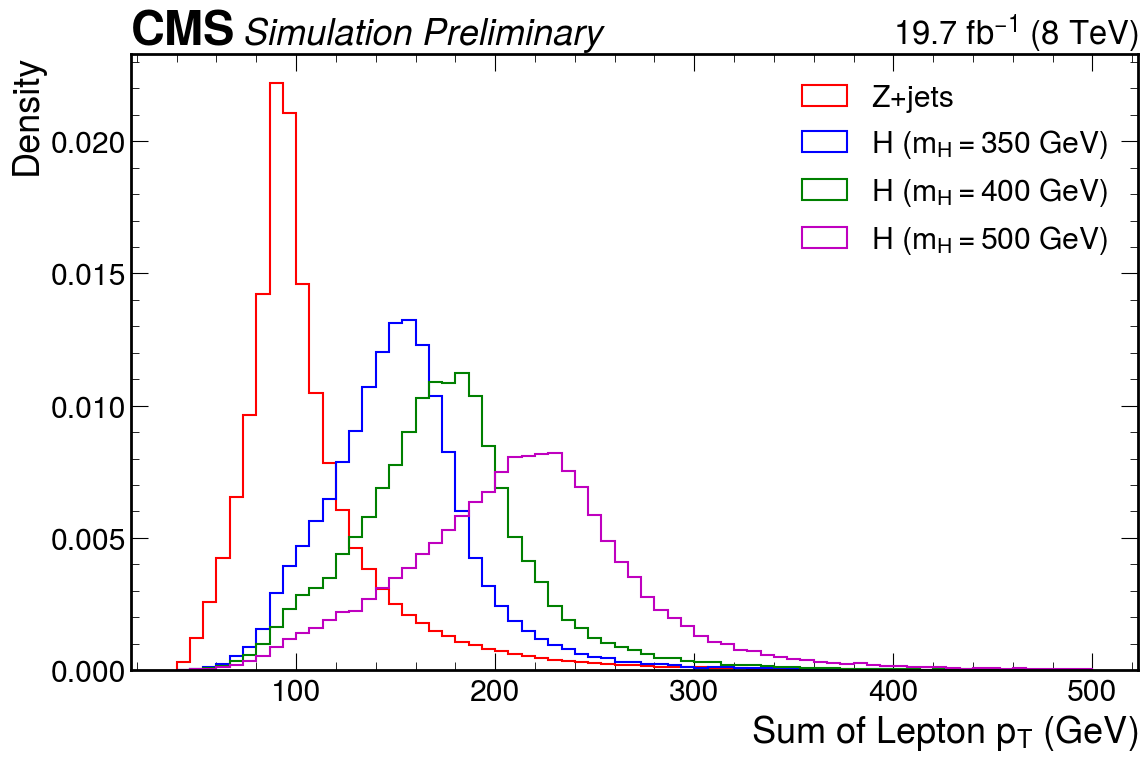

In [40]:
var = "ptl_sum"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [40, 500] # Adjust range as needed
bins = 70
xl = r"Sum of Lepton $p_T$ (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

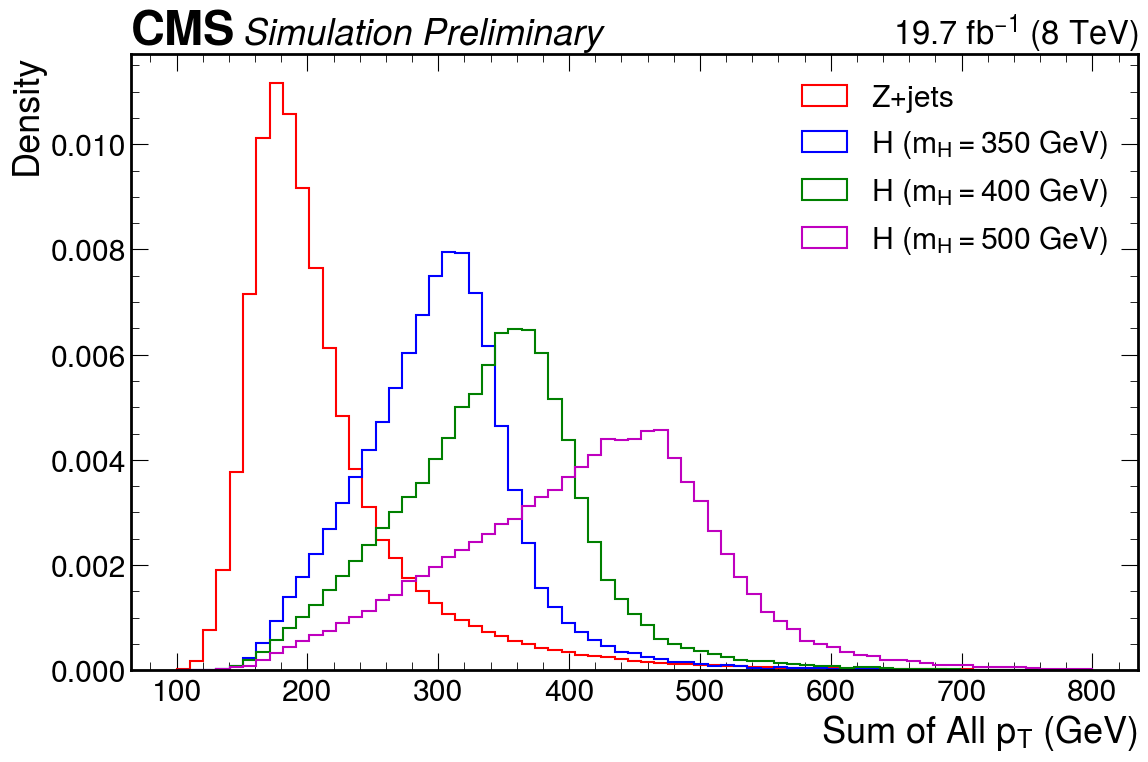

In [35]:
var = "pt_all_sum"
df_name_list = [ZJets, Higgs350, Higgs400, Higgs500]
lum_df_list = [lumi_zjets, lumi_higgs350, lumi_higgs400, lumi_higgs500]
label_list = ["Z+jets", "H ($m_H=350$ GeV)", "H ($m_H=400$ GeV)", "H ($m_H=500$ GeV)"]
x_range = [100, 800] # Adjust range as needed
bins = 70
xl = r"Sum of All $p_T$ (GeV)"
Compare_Variables(var, df_name_list, lum_df_list, label_list, x_range, bins,xl)

### B) Discrimination Strategy

#### B.1) Optimal Cut Selection

From the analysis of section A, we saww that there are 3 main candidates for variables that can offer a good cut to discriminate between background and signal. They are:


*   Angular likelihood discriminat
*   Invariant mass of all particles
*   Transverse momentum of all particles

The objective now is to see what is the optimal cutting strategy, both the cutting points $X$ and the order of the cuts. The $X$'s can be found via the function `find_cut`, but the order we have to check and see which one give the best final significance $S=N_S/\sqrt{N_B}$.



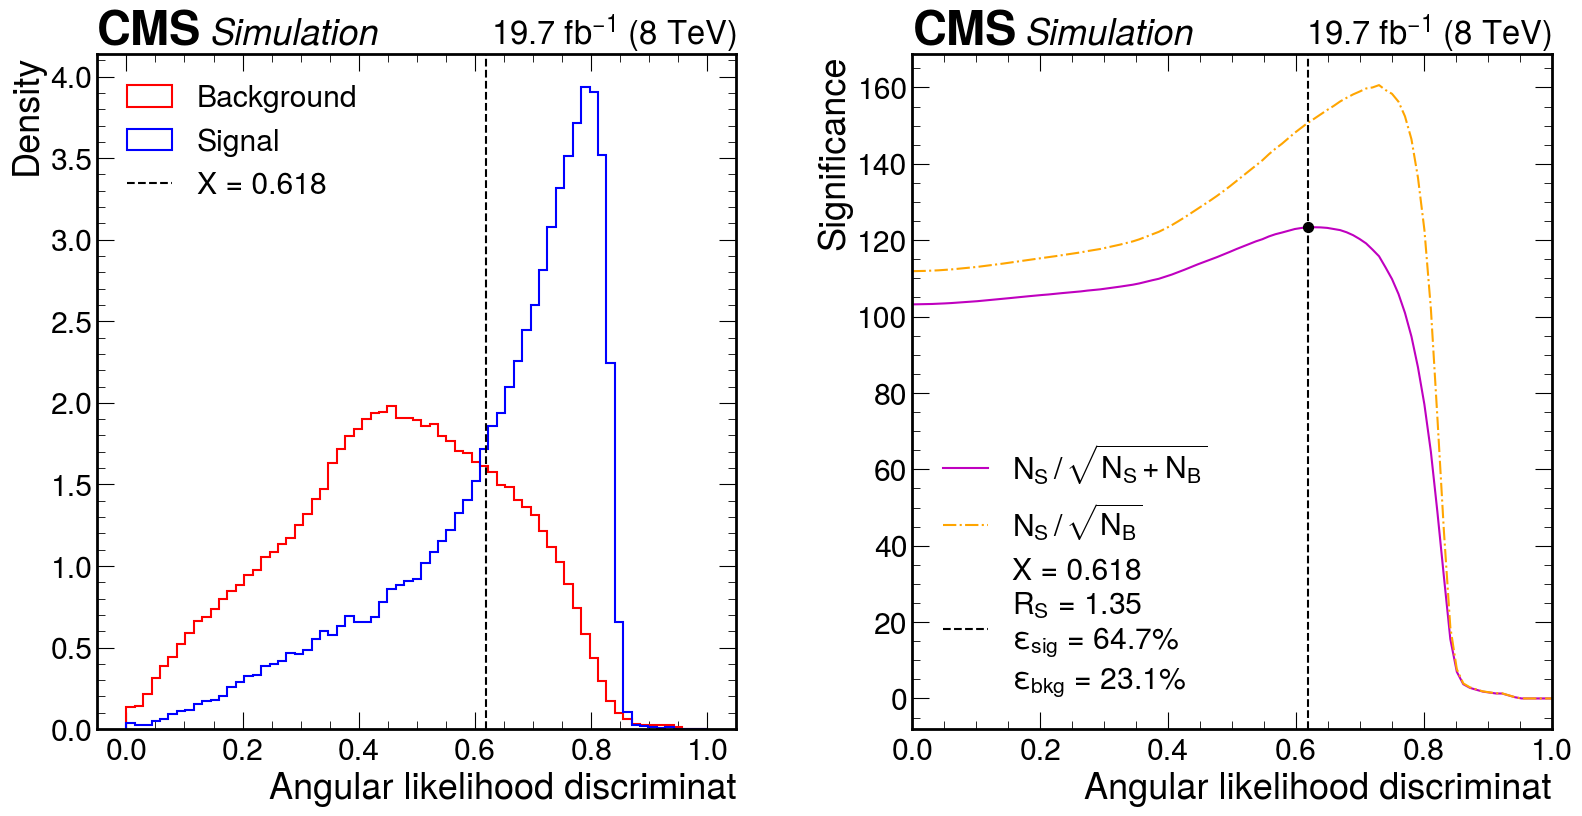

In [45]:
result_ld = find_cut(Higgs350, ZJets, "ld")
plot_cut(sgn=Higgs350, bkg=ZJets, var="ld", result=result_ld, x_range=[0, 1], xl=r"Angular likelihood discriminat")

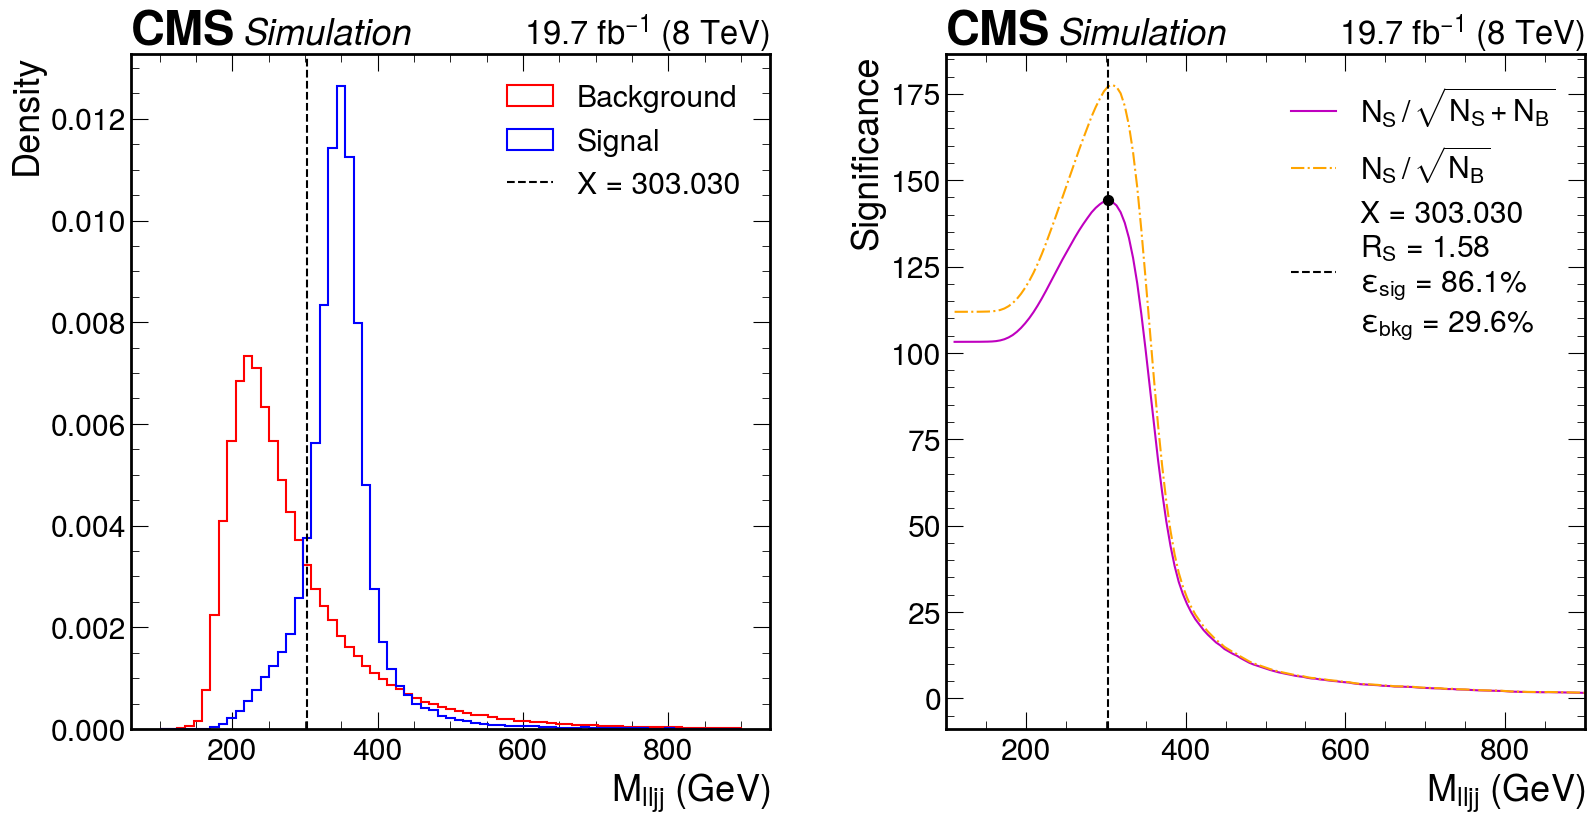

In [51]:
result_ld = find_cut(Higgs350, ZJets, "Mlljj")
plot_cut(sgn=Higgs350, bkg=ZJets, var="Mlljj", result=result_ld, x_range=[100, 900], xl=r"$M_{lljj}$ (GeV)")

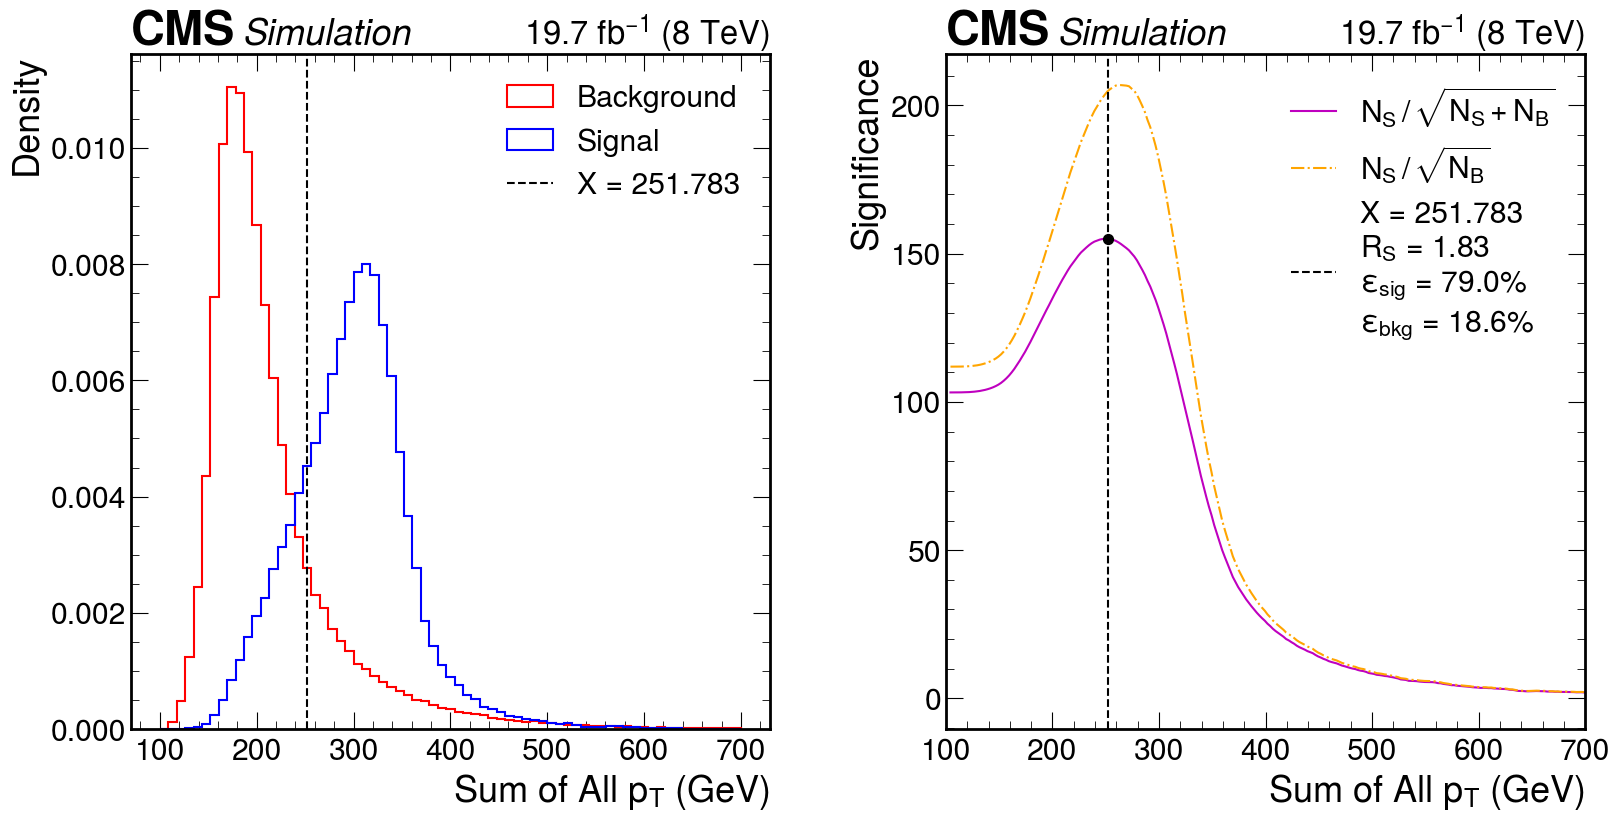

In [28]:
result_pt_all_sum = find_cut(Higgs350, ZJets, "pt_all_sum")
plot_cut(sgn=Higgs350, bkg=ZJets, var="pt_all_sum", result=result_pt_all_sum, x_range=[100, 700], xl=r"Sum of All $p_T$ (GeV)")